# Notebook 04 — BALD: decomporre l'incertezza (MNIST)

**Concetto.** La posterior sulla testa induce, per ogni input, una distribuzione di
predizioni. L'incertezza predittiva **totale** si decompone in due parti (BALD):

$$\underbrace{H\!\big[\mathbb E_\theta\, p(y|x,\theta)\big]}_{\text{totale}}
=\underbrace{\mathbb E_\theta\, H\!\big[p(y|x,\theta)\big]}_{\text{aleatoria}}
+\underbrace{\Big(H[\mathbb E_\theta p]-\mathbb E_\theta H[p]\Big)}_{\text{epistemica (= mutual information)}}$$

- **aleatoria** = ambiguità *intrinseca* del dato (classi che si sovrappongono). Non
  sparisce con più dati.
- **epistemica** = incertezza *sui pesi*: alta dove le feature escono dal supporto della
  source. È **questo** il segnale che rivela lo shift/OOD.

**Prova di comprensione (obiettivo).** Verificare l'identità e la non-negatività, poi il
check **semantico** su immagini:
(a) cifre MNIST ambigue → domina l'**aleatoria**;
(b) immagini Fashion-MNIST (OOD) → domina l'**epistemica**.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # evita OMP Error #15 (Windows)

import sys, pathlib
# root del progetto = cartella che contiene 'src', trovata a partire dal notebook
here = pathlib.Path.cwd()
for base in [here, *here.parents]:
    if (base / "code_v2" / "src" / "laplace_core.py").is_file():
        sys.path.insert(0, str(base)); PROJ = base / "code_v2"; break
else:
    raise RuntimeError("cartella 'code_v2/src' non trovata: apri il progetto dalla sua root")
import numpy as np, torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
import torchvision, torchvision.transforms as T

from code_v2.src.bayesian_model import SmallCNN, extract, augment, LastLayerLaplace

np.random.seed(0); torch.manual_seed(0)
DEVICE = "cpu"; RNG = np.random.default_rng(0)

## 1. Carico il modello bayesiano source dal Notebook 03

Ricostruiamo la CNN congelata e la posterior della testa dagli artefatti salvati:
è la stessa "generazione source" del NB 03, non ne rifacciamo il training (pipeline ordinata).

In [2]:
model = SmallCNN(n_classes=10)
model.load_state_dict(torch.load(str(PROJ / "data" / "mnist_cnn.pt")))
model.eval()

d = np.load(str(PROJ / "data" / "mnist_laplace.npz"))
laplace = LastLayerLaplace(theta_map=d["theta_map"], cov=d["cov"],
                           K=int(d["K"]), Dp=int(d["Dp"]))
print("modello + posterior caricati dal NB 03")

modello + posterior caricati dal NB 03


C:\Users\aless\AppData\Local\Temp\ipykernel_9816\2759873335.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(str(PROJ / "data" / "mnist_c

## 2. Verifica dell'identità BALD

Su un blocco di immagini MNIST: totale = aleatoria + epistemica, con epistemica ≥ 0.

In [3]:
tf = T.ToTensor()
mnist_te = torchvision.datasets.MNIST(str(PROJ / "data"), train=False, download=True, transform=tf)
mnist_loader = DataLoader(Subset(mnist_te, range(2000)), batch_size=1024)

Phi_m, y_m, _ = extract(model, mnist_loader, device=DEVICE)
Pm = augment(Phi_m)
pred_m = laplace.predictive(Pm, M=200, rng=RNG)

lhs = pred_m["total"]; rhs = pred_m["aleatoric"] + pred_m["epistemic"]
print("identità totale = aleatoria + epistemica:", np.allclose(lhs, rhs))
print("epistemica >= 0 (tutti i punti):", (pred_m["epistemic"] > -1e-9).all())

identità totale = aleatoria + epistemica: True
epistemica >= 0 (tutti i punti): True


## 3a. Aleatoria: le cifre ambigue

Ordiniamo le immagini MNIST per **aleatoria** decrescente e guardiamo le più alte:
sono cifre scritte male / a cavallo fra due classi (tipicamente 4/9, 3/5, 7/9…). La
predittiva media mette massa su **due** classi → è ambiguità intrinseca, non mancanza
di dati.

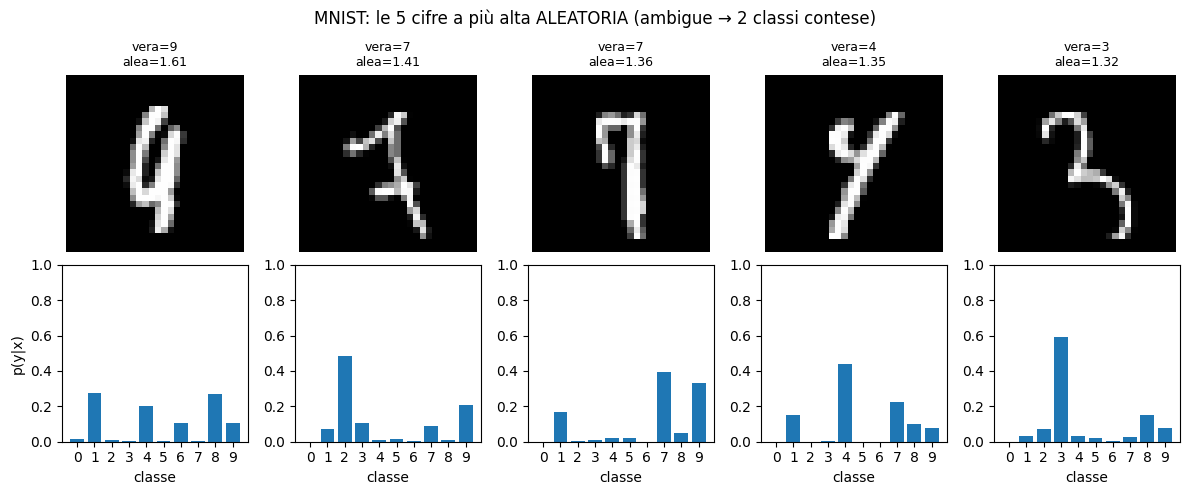

In [4]:
imgs_m = mnist_te.data[:2000].numpy()
top_alea = np.argsort(-pred_m["aleatoric"])[:5]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for j, idx in enumerate(top_alea):
    axes[0, j].imshow(imgs_m[idx], cmap="gray"); axes[0, j].axis("off")
    axes[0, j].set_title(f"vera={y_m[idx]}\nalea={pred_m['aleatoric'][idx]:.2f}", fontsize=9)
    axes[1, j].bar(range(10), pred_m["probs"][idx]); axes[1, j].set_xticks(range(10))
    axes[1, j].set_ylim(0, 1); axes[1, j].set_xlabel("classe")
axes[1, 0].set_ylabel("p(y|x)")
fig.suptitle("MNIST: le 5 cifre a più alta ALEATORIA (ambigue → 2 classi contese)")
fig.tight_layout(); plt.show()

## 3b. Epistemica: gli input fuori distribuzione (Fashion-MNIST)

Fashion-MNIST ha lo stesso formato (1×28×28) ma classi **mai viste** dal modello:
è OOD puro. La testa MAP predice comunque con sicurezza (overconfidence ReLU), ma la
**epistemica** della posterior deve schizzare in alto rispetto a MNIST.

In [5]:
fashion = torchvision.datasets.FashionMNIST(str(PROJ / "data"), train=False, download=True, transform=tf)
fashion_loader = DataLoader(Subset(fashion, range(2000)), batch_size=1024)

Phi_f, _, _ = extract(model, fashion_loader, device=DEVICE)
Pf = augment(Phi_f)
pred_f = laplace.predictive(Pf, M=200, rng=RNG)

print(f"epistemica media  — MNIST (in-dist): {pred_m['epistemic'].mean():.3f}")
print(f"epistemica media  — Fashion (OOD)  : {pred_f['epistemic'].mean():.3f}")
print(f"rapporto OOD/in-dist: {pred_f['epistemic'].mean()/pred_m['epistemic'].mean():.1f}x")

epistemica media  — MNIST (in-dist): 0.010
epistemica media  — Fashion (OOD)  : 0.120
rapporto OOD/in-dist: 11.5x


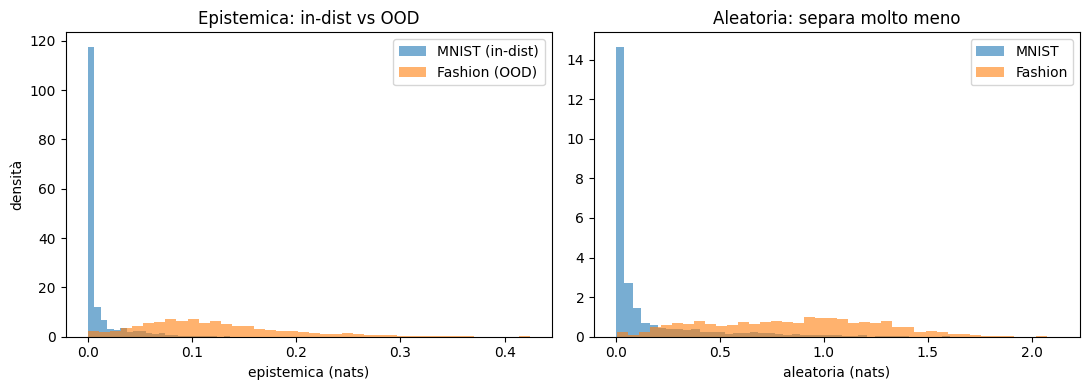

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(pred_m["epistemic"], bins=40, alpha=.6, density=True, label="MNIST (in-dist)")
axes[0].hist(pred_f["epistemic"], bins=40, alpha=.6, density=True, label="Fashion (OOD)")
axes[0].set_xlabel("epistemica (nats)"); axes[0].set_ylabel("densità")
axes[0].set_title("Epistemica: in-dist vs OOD"); axes[0].legend()

# stessa cosa per l'aleatoria: NON deve separare bene (non è un rivelatore di shift)
axes[1].hist(pred_m["aleatoric"], bins=40, alpha=.6, density=True, label="MNIST")
axes[1].hist(pred_f["aleatoric"], bins=40, alpha=.6, density=True, label="Fashion")
axes[1].set_xlabel("aleatoria (nats)"); axes[1].set_title("Aleatoria: separa molto meno")
axes[1].legend()
fig.tight_layout(); plt.show()

## Riassunto

- L'identità BALD **totale = aleatoria + epistemica** è verificata, epistemica ≥ 0.
- **Aleatoria** ↔ ambiguità *dentro* la distribuzione (cifre confondibili).
- **Epistemica** ↔ input *fuori* distribuzione: separa nettamente Fashion (OOD) da MNIST,
  mentre l'aleatoria no. → è **l'epistemica** il rivelatore di shift/OOD.

Questo è il segnale che il **Notebook 05** (`05_shift_mnist.ipynb`) quantifica in
condizioni controllate (Rotated-MNIST, dove l'angolo di rotazione è la verità nota sullo
shift), che il **Notebook 06** usa per adattare davvero il modello, e che i **Notebook
09-12** riprendono su uno shift reale fra domini (SVHN -> MNIST/USPS).

> *Nota.* Una versione precedente di questa cella rimandava a un notebook su dati reali
> UCI-HAR: quell'esperimento vive nel progetto principale, **non** in `code_v2`. Qui il
> ruolo di "shift reale, senza verità nota" è svolto dalla traccia digits (Notebook 08-15).